In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import glob 
# import xrft as xt
from eofs.xarray import Eof
import pandas as pd
import scipy
from mpl_toolkits.basemap import Basemap
import datetime
from matplotlib.dates import MonthLocator, DateFormatter
import datetime as dt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from matplotlib.dates import YearLocator
from scipy.stats import pearsonr as p
# from sklearn.metrics import r2_score
plt.rcParams['font.weight']='bold'
import xskillscore as xs
plt.style.use('default')

In [2]:
# error=xr.open_dataset('TA_final_').TA
# error
ta=xr.open_dataset('TA_final_ensemble.nc').TA

# NEW_VERSION

# Spatial Trend TA

In [20]:
from scipy.stats import linregress
def calculate_trend(data_array):
    slopes = np.apply_along_axis(lambda y: linregress(range(len(y)), y).slope*12, axis=0, arr=data_array)
    #pval = np.apply_along_axis(lambda y: linregress(range(len(y)), y).slope, axis=0, arr=data_array)
    return slopes


from scipy.stats import linregress
def calculate_pval(data_array):
    pvals = np.apply_along_axis(lambda y: linregress(range(len(y)), y).pvalue, axis=0, arr=data_array)
    #pval = np.apply_along_axis(lambda y: linregress(range(len(y)), y).slope, axis=0, arr=data_array)
    return pvals

In [37]:
trend_full_ta = xr.apply_ufunc(calculate_trend, ta,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])
pval_full_ta = xr.apply_ufunc(calculate_pval, ta,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [25]:
import os
os.getcwd()

'/home/prasanna/ML_XGboost/CMEMS_0.25deg'

In [5]:
# (trend_full*12).sel(Lon=slice(78,100)).mean()

# Salinity Normalized

In [8]:
full_sal=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_salt_TA.nc').so.sel(longitude=slice(50,100),latitude=slice(0,26))

In [9]:
import xskillscore as xs

# Others

In [12]:
from scipy.stats import linregress
def reg_line(a):
    slope, intercept, rvalue, pvalue, stderr = linregress(np.arange(1,len(a)+1),a)
    reg=slope*np.arange(1,len(a)+1)+intercept
    return reg,slope*12,pvalue,stderr

In [13]:
from scipy.stats import pearsonr as pr

In [14]:
sal_NIO

<xarray.DataArray 'so' (time: 336, latitude: 313, longitude: 600)>
[63100800 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2020-12-16T12:00:00
  * longitude  (longitude) float32 50.0 50.08 50.17 50.25 ... 99.75 99.83 99.92
  * latitude   (latitude) float32 0.0 0.08333 0.1667 0.25 ... 25.83 25.92 26.0
    depth      float32 ...
Attributes:
    standard_name:  sea_water_salinity
    long_name:      Salinity
    units:          1e-3
    unit_long:      Practical Salinity Unit
    cell_methods:   area: mean
    _ChunkSizes:    [   1   17  681 1440]

# MLD_SST_SSS Trend spatial

In [15]:
full_temp=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_sst_TA.nc').thetao.sel(longitude=slice(50,100),latitude=slice(0,26)).compute()
full_mld=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_mld_TA.nc').mlotst.sel(longitude=slice(50,100),latitude=slice(0,26)).compute()
full_sal=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_salt_TA.nc').so.sel(longitude=slice(50,100),latitude=slice(0,26)).compute()

In [17]:
trend_temp_spatial=xr.apply_ufunc(calculate_trend,full_temp,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [21]:
pval_temp_spatial=xr.apply_ufunc(calculate_pval,full_temp,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [22]:
trend_sal_spatial=xr.apply_ufunc(calculate_trend,full_sal,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [23]:
pval_sal_spatial=xr.apply_ufunc(calculate_pval,full_sal,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [24]:
trend_mld_spatial=xr.apply_ufunc(calculate_trend,full_mld,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [25]:
pval_mld_spatial=xr.apply_ufunc(calculate_pval,full_mld,input_core_dims=[['time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [26]:
# (pval_mld_spatial).where(pval_mld_spatial<=0.1).plot(robust=True)

In [27]:
import cmocean 

# NEW SST,SSS,MLD

/tmp/ipykernel_4112750/1758708526.py:33: UserWarning: The following kwargs were not used by contour: 'robust'
  qq=ax[0].contourf(x,y,trend_temp_spatial,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-0.04,0.0425,.0025),robust=True)


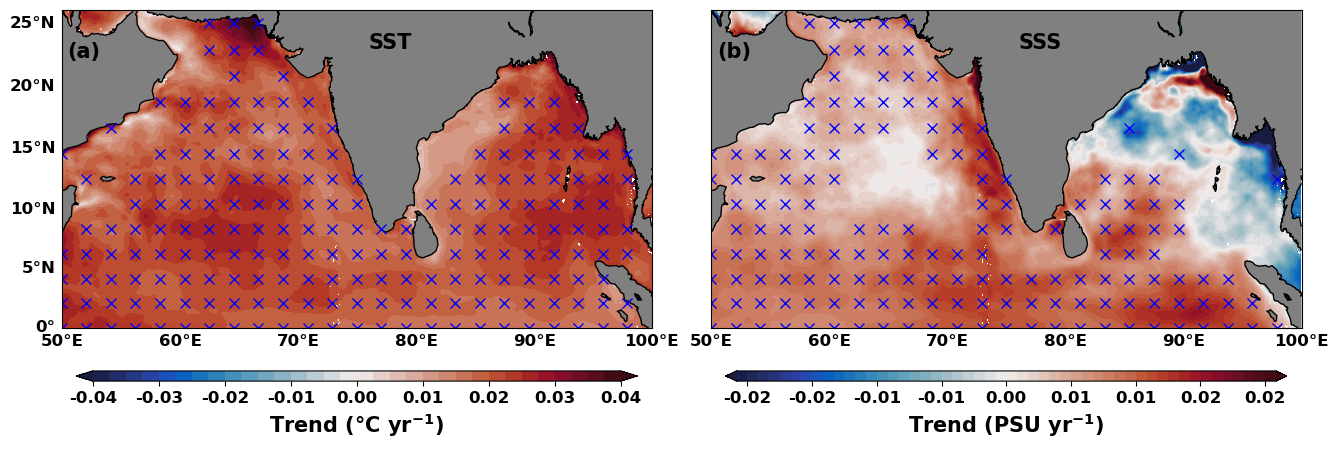

In [35]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,14),sharey=True)
plt.subplots_adjust(wspace=0.1,hspace=-0.1)

map = Basemap(projection='merc', resolution='l',
                llcrnrlat=0, urcrnrlat = 26,
                llcrnrlon=50, urcrnrlon = 100)
kk=21

mask_sig = pval_temp_spatial <= 0.1
mask_sig_sal = pval_sal_spatial <= 0.1

skip = 25

mask_sparse = np.zeros_like(mask_sig, dtype=bool)
mask_sparse[::skip, ::skip] = mask_sig[::skip, ::skip]


def mask_spa(mask):
    mask_sparse = np.zeros_like(mask, dtype=bool)
    mask_sparse[::skip, ::skip] = mask[::skip, ::skip]
    return mask_sparse

    


lon,lat=np.meshgrid(full_temp.longitude,full_temp.latitude)
x,y=map(lon,lat)


# lon1, lat1 = np.meshgrid(trend_temp_spatial.lon, trend_temp_spatial.lat)

qq=ax[0].contourf(x,y,trend_temp_spatial,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-0.04,0.0425,.0025),robust=True)
pp=ax[1].contourf(x,y,trend_sal_spatial,55,cmap=cmocean.cm.balance,levels=np.arange(-0.025,0.026,0.001),extend='both')


for i in range(2):
    map.fillcontinents(color='gray',lake_color='aqua',ax=ax[i])
    map.drawcoastlines(ax=ax[i])
     
    if i in [0]:
        map.drawparallels(range(-90, 100, 5),ax=ax[i], labels=[1,0,0,0], color='w', zorder=0,fontsize=12)
    if i in [0,1]:
        map.drawmeridians(range(50, 120, 10),labels=[0,0,0,1],color='w',ax=ax[i], zorder=0,fontsize=12)


ax[0].plot(
    x[mask_sparse], y[mask_sparse],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)
ax[1].plot(
    x[mask_spa(mask_sig_sal)], y[mask_spa(mask_sig_sal)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)


cb=fig.colorbar(pp,ax=ax[1],pad=0.04,orientation='horizontal',shrink=0.95,fraction=0.1,aspect=55,format='%.2f',extendfrac='auto',extend='both')
cb1=fig.colorbar(qq,ax=ax[0],pad=0.04,orientation='horizontal',shrink=0.95,fraction=0.1,aspect=55,format='%.2f',extendfrac='auto',extend='both')


cb1.set_label(u"Trend (\N{DEGREE SIGN}C yr$^{-1}$)", rotation=0,fontsize=15,fontweight='bold')
cb.set_label(u"Trend (PSU yr$^{-1}$)", rotation=0,fontsize=15,fontweight='bold')


cb.ax.tick_params(labelsize=12) 
cb1.ax.tick_params(labelsize=12) 

lont,latt=map(76,23)
ax[0].text(lont,latt,'SST', fontsize=15, fontweight="bold")
ax[1].text(lont,latt,'SSS', fontsize=15, fontweight="bold")


for i, ax in enumerate(ax):
        label = f"({chr(ord('a') + i)})"
        ax.text(0.01, 0.9, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

# fig.suptitle('Trend (units yr$^{-1}$)',x=0.51,y=.48,fontsize=20,fontweight='bold')
# plt.savefig('spatial_trend_pvalue_90%_SST_SSS.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')

/tmp/ipykernel_4112750/27189166.py:27: UserWarning: The following kwargs were not used by contour: 'robust'
  qq=ax[0].contourf(x,y,trend_mld_spatial,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-0.25,0.251,.01),robust=True)


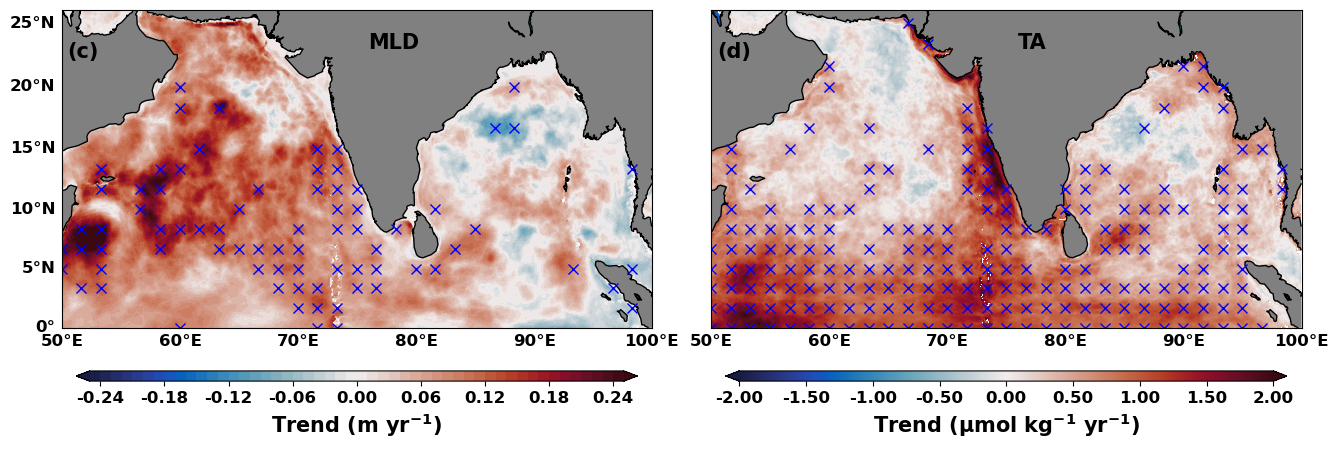

In [39]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,14),sharey=True)
plt.subplots_adjust(wspace=0.1,hspace=-0.1)

map = Basemap(projection='merc', resolution='l',
                llcrnrlat=0, urcrnrlat = 26,
                llcrnrlon=50, urcrnrlon = 100)
kk=21

mask_sig_mld = pval_mld_spatial <= 0.1
mask_sig_ta = pval_full_ta <= 0.1

skip = 20


def mask_spa(mask):
    mask_sparse = np.zeros_like(mask, dtype=bool)
    mask_sparse[::skip, ::skip] = mask[::skip, ::skip]
    return mask_sparse

lon,lat=np.meshgrid(full_temp.longitude,full_temp.latitude)
x,y=map(lon,lat)


# lon1, lat1 = np.meshgrid(trend_temp_spatial.lon, trend_temp_spatial.lat)

qq=ax[0].contourf(x,y,trend_mld_spatial,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-0.25,0.251,.01),robust=True)
pp=ax[1].contourf(x,y,trend_full_ta,55,cmap=cmocean.cm.balance,levels=np.arange(-2,2.001,0.001),extend='both')


for i in range(2):
    map.fillcontinents(color='gray',lake_color='aqua',ax=ax[i])
    map.drawcoastlines(ax=ax[i])
     
    if i in [0]:
        map.drawparallels(range(-90, 100, 5),ax=ax[i], labels=[1,0,0,0], color='w', zorder=0,fontsize=12)
    if i in [0,1]:
        map.drawmeridians(range(50, 120, 10),labels=[0,0,0,1],color='w',ax=ax[i], zorder=0,fontsize=12)


ax[0].plot(
    x[mask_spa(mask_sig_mld)], y[mask_spa(mask_sig_mld)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)

ax[1].plot(
    x[mask_spa(mask_sig_ta)], y[mask_spa(mask_sig_ta)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)


cb=fig.colorbar(pp,ax=ax[1],pad=0.04,orientation='horizontal',shrink=0.95,fraction=0.1,ticks=np.arange(-2,2.01,.5),aspect=55,format='%.2f',extendfrac=.025,extend='both')
cb1=fig.colorbar(qq,ax=ax[0],pad=0.04,orientation='horizontal',shrink=0.95,fraction=0.1,aspect=55,format='%.2f',extendfrac=.025,extend='both')
# cb1.set_label('', rotation=90,fontsize=12,fontweight='bold')
cb.ax.tick_params(labelsize=12) 
cb1.ax.tick_params(labelsize=12) 

lont,latt=map(76,23)
ax[0].text(lont,latt,'MLD', fontsize=15, fontweight="bold")
ax[1].text(lont,latt,'TA', fontsize=15, fontweight="bold")

cb1.set_label(u"Trend (m yr$^{-1}$)", rotation=0,fontsize=15,fontweight='bold')
cb.set_label(u"Trend (\u03BCmol kg$^{-1}$ yr$^{-1}$)", rotation=0,fontsize=15,fontweight='bold')


for i, ax in enumerate(ax):
        label = f"({chr(ord('c') + i)})"
        ax.text(0.01, 0.9, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

# fig.suptitle('Trend (units yr$^{-1}$)',x=0.51,y=.48,fontsize=20,fontweight='bold')
# plt.savefig('spatial_trend_pvalue_90%_MLD_TA.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')

/tmp/ipykernel_105146/4257401562.py:30: UserWarning: The following kwargs were not used by contour: 'robust'
  qq=ax[0].contourf(x,y,trend_full_nta_35,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-1.5,1.51,.01),robust=True)


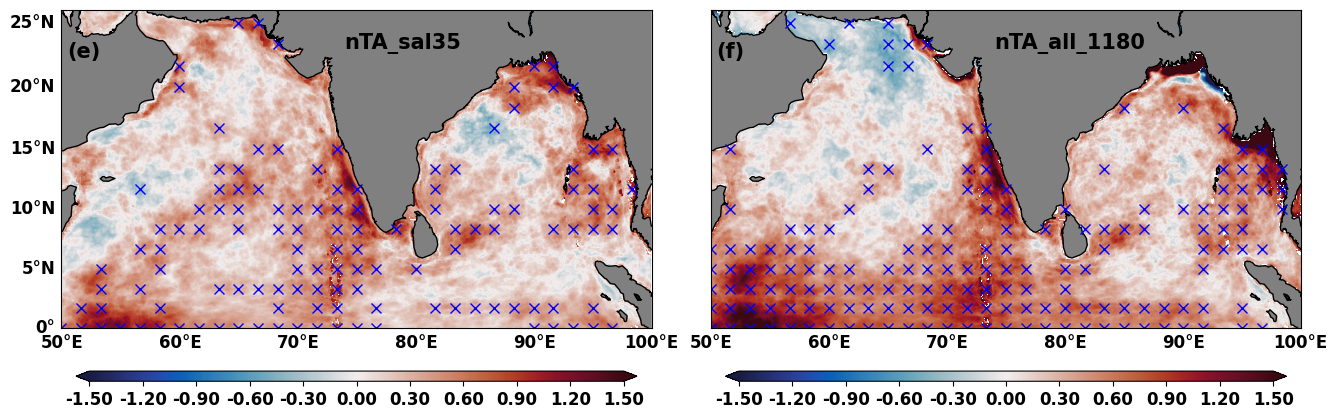

In [168]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,14),sharey=True)
plt.subplots_adjust(wspace=0.1,hspace=-0.1)

map = Basemap(projection='merc', resolution='l',
                llcrnrlat=0, urcrnrlat = 26,
                llcrnrlon=50, urcrnrlon = 100)
kk=21

mask_sig_nta35 = pval_full_nta_35 <= 0.1
mask_sig_nta1180 = pval_full_nta_1180 <= 0.1

skip = 20


def mask_spa(mask):
    mask_sparse = np.zeros_like(mask, dtype=bool)
    mask_sparse[::skip, ::skip] = mask[::skip, ::skip]
    return mask_sparse

    


lon,lat=np.meshgrid(full_temp.longitude,full_temp.latitude)
x,y=map(lon,lat)


# lon1, lat1 = np.meshgrid(trend_temp_spatial.lon, trend_temp_spatial.lat)

qq=ax[0].contourf(x,y,trend_full_nta_35,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-1.5,1.51,.01),robust=True)
pp=ax[1].contourf(x,y,trend_full_nta_1180,55,cmap=cmocean.cm.balance,levels=np.arange(-1.5,1.5001,0.001),extend='both')


for i in range(2):
    map.fillcontinents(color='gray',lake_color='aqua',ax=ax[i])
    map.drawcoastlines(ax=ax[i])
     
    if i in [0]:
        map.drawparallels(range(-90, 100, 5),ax=ax[i], labels=[1,0,0,0], color='w', zorder=0,fontsize=12)
    if i in [0,1]:
        map.drawmeridians(range(50, 120, 10),labels=[0,0,0,1],color='w',ax=ax[i], zorder=0,fontsize=12)


ax[0].plot(
    x[mask_spa(mask_sig_nta35)], y[mask_spa(mask_sig_nta35)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)

ax[1].plot(
    x[mask_spa(mask_sig_nta1180)], y[mask_spa(mask_sig_nta1180)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)


cb=fig.colorbar(pp,ax=ax[1],pad=0.04,orientation='horizontal',ticks=np.arange(-1.5,1.51,.3),shrink=0.95,fraction=0.1,aspect=55,format='%.2f',extendfrac=.025,extend='both')
cb1=fig.colorbar(qq,ax=ax[0],pad=0.04,orientation='horizontal',shrink=0.95,ticks=np.arange(-1.5,1.51,.3),fraction=0.1,aspect=55,format='%.2f',extendfrac=.025,extend='both')
# cb1.set_label('', rotation=90,fontsize=12,fontweight='bold')
cb.ax.tick_params(labelsize=12) 
cb1.ax.tick_params(labelsize=12) 

lont,latt=map(74,23)
ax[0].text(lont,latt,'nTA_sal35', fontsize=15, fontweight="bold")
ax[1].text(lont,latt,'nTA_all_1180', fontsize=15, fontweight="bold")


for i, ax in enumerate(ax):
        label = f"({chr(ord('e') + i)})"
        ax.text(0.01, 0.9, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

# fig.suptitle('Trend (units yr$^{-1}$)',x=0.51,y=.48,fontsize=20,fontweight='bold')
# plt.savefig('spatial_trend_pvalue_90%_nTA_diff.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')

# nTA_Clim

In [7]:
nTA_clim_sal = xr.open_dataset('nTA_using_clim_salinity.nc').TA

trend_full_nta_clim_sal = xr.apply_ufunc(calculate_trend, nTA_clim_sal,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])
pval_full_nta_clim_sal = xr.apply_ufunc(calculate_pval, nTA_clim_sal,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])

In [16]:
import cmocean

/tmp/ipykernel_2874290/2870700029.py:30: UserWarning: The following kwargs were not used by contour: 'robust'
  qq=ax[0].contourf(x,y,trend_full_nta_clim_sal,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-2,2.01,.01),robust=True)


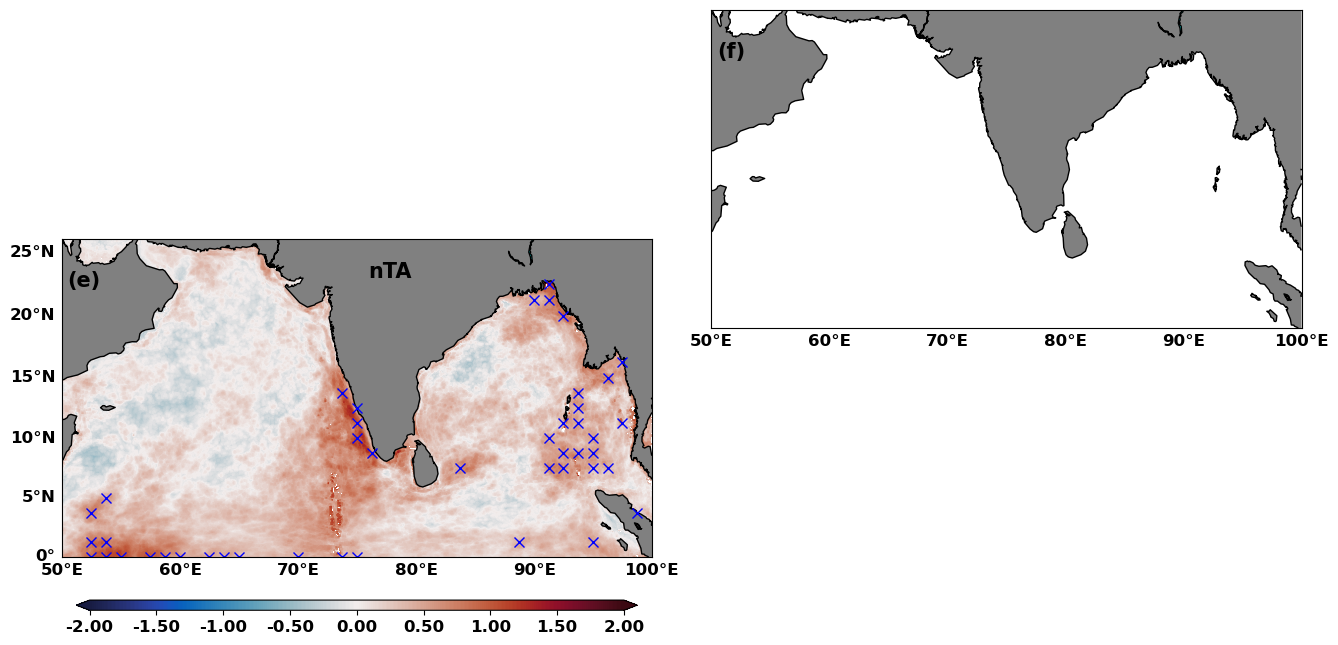

In [62]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,14),sharey=True)
plt.subplots_adjust(wspace=0.1,hspace=-0.1)

map = Basemap(projection='merc', resolution='l',
                llcrnrlat=0, urcrnrlat = 26,
                llcrnrlon=50, urcrnrlon = 100)
kk=21

mask_sig_nta_clim_sal = pval_full_nta_clim_sal <= 0.02
# mask_sig_nta1180 = pval_full_nta_1180 <= 0.1

skip = 15


def mask_spa(mask):
    mask_sparse = np.zeros_like(mask, dtype=bool)
    mask_sparse[::skip, ::skip] = mask[::skip, ::skip]
    return mask_sparse

    


lon,lat=np.meshgrid(nTA_clim_sal.Lon,nTA_clim_sal.Lat)
x,y=map(lon,lat)


# lon1, lat1 = np.meshgrid(trend_temp_spatial.lon, trend_temp_spatial.lat)

qq=ax[0].contourf(x,y,trend_full_nta_clim_sal,55,cmap=cmocean.cm.balance,extend='both',levels=np.arange(-2,2.01,.01),robust=True)
# pp=ax[1].contourf(x,y,trend_full_nta_1180,55,cmap=cmocean.cm.balance,levels=np.arange(-1.5,1.5001,0.001),extend='both')


for i in range(2):
    map.fillcontinents(color='gray',lake_color='aqua',ax=ax[i])
    map.drawcoastlines(ax=ax[i])
     
    if i in [0]:
        map.drawparallels(range(-90, 100, 5),ax=ax[i], labels=[1,0,0,0], color='w', zorder=0,fontsize=12)
    if i in [0,1]:
        map.drawmeridians(range(50, 120, 10),labels=[0,0,0,1],color='w',ax=ax[i], zorder=0,fontsize=12)


ax[0].plot(
    x[mask_spa(mask_sig_nta_clim_sal)], y[mask_spa(mask_sig_nta_clim_sal)],
    'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
)

# ax[1].plot(
#     x[mask_spa(mask_sig_nta1180)], y[mask_spa(mask_sig_nta1180)],
#     'x', color='blue', markersize=7, label='p ≤ 0.1',linewidth=10
# )


# cb=fig.colorbar(pp,ax=ax[1],pad=0.04,orientation='horizontal',ticks=np.arange(-1.5,1.51,.3),shrink=0.95,fraction=0.1,aspect=55,format='%.2f',extendfrac=.025,extend='both')
cb1=fig.colorbar(qq,ax=ax[0],pad=0.04,orientation='horizontal',shrink=0.95,ticks=np.arange(-2,2.1,.5),fraction=0.1,aspect=55,format='%.2f',extendfrac=.025,extend='both')
# cb1.set_label('', rotation=90,fontsize=12,fontweight='bold')
# cb.ax.tick_params(labelsize=12) 
cb1.ax.tick_params(labelsize=12) 

lont,latt=map(76,23)
ax[0].text(lont,latt,'nTA', fontsize=15, fontweight="bold")
# ax[1].text(lont,latt,'nTA_all_1180', fontsize=15, fontweight="bold")


for i, ax in enumerate(ax):
        label = f"({chr(ord('e') + i)})"
        ax.text(0.01, 0.9, label, transform=ax.transAxes, fontsize=15, fontweight="bold", va="top")

# fig.suptitle('Trend (units yr$^{-1}$)',x=0.51,y=.48,fontsize=20,fontweight='bold')
# plt.savefig('spatial_trend_pvalue_90%_nTA_diff.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')

In [64]:
ta_climatology=ta.groupby('Time.month').mean()
ta_climatology_repeat=xr.concat([ta_climatology]*28,dim='month')
ta_climatology_repeat=ta_climatology_repeat.rename({'month':'Time'})
ta_climatology_repeat['Time'] = ta.Time

In [78]:
ALK_residue = ta - ta.mean(dim='Time')#ta_climatology_repeat

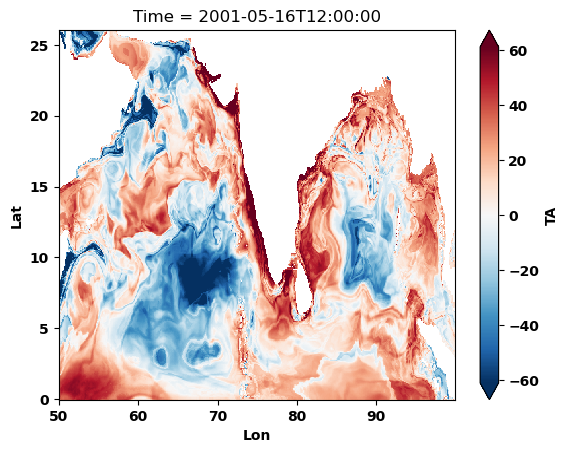

In [83]:
ALK_residue.isel(Time=100).plot(robust=True)

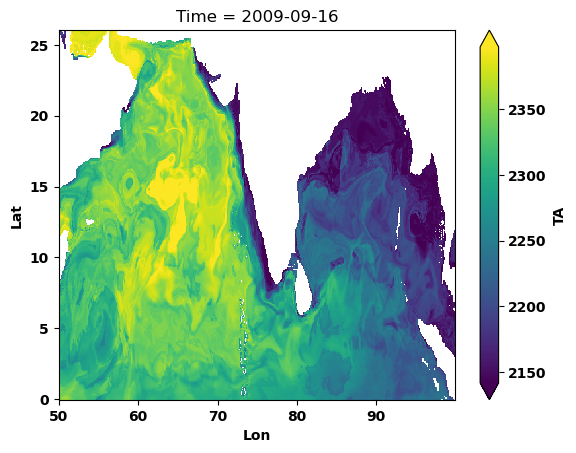

In [85]:
ta.isel(Time=200).plot(robust=True)

In [79]:
trend_ta_res = xr.apply_ufunc(calculate_trend, ALK_residue,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])
pval_ta_res = xr.apply_ufunc(calculate_pval, ALK_residue,input_core_dims=[['Time']],vectorize=True,dask='parallelized',output_dtypes=[float])

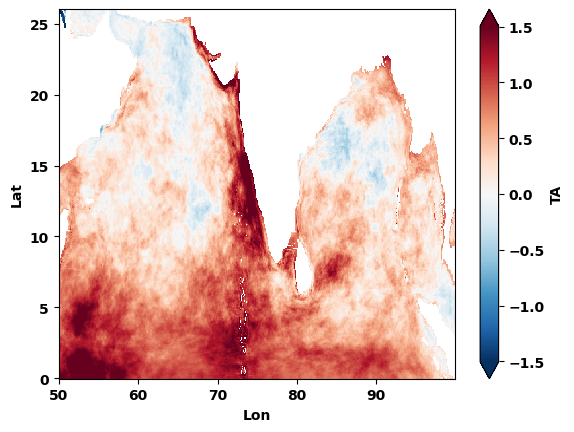

In [80]:
trend_ta_res.plot(robust=True)

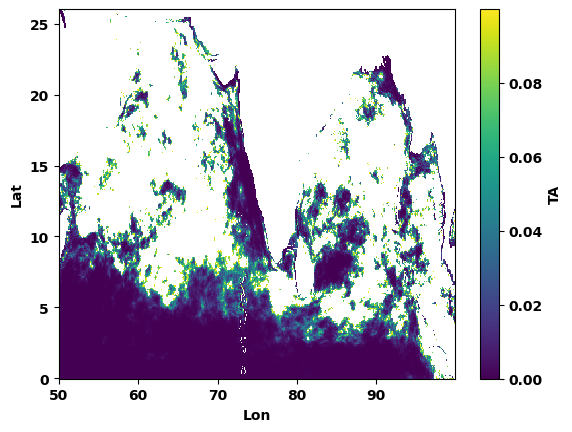

In [81]:
pval_ta_res.where(pval_ta_res<=0.1).plot()

In [90]:
# All_840=xr.open_dataset('nTA_TAriver_840_NIO.nc').nTA

# KDE plot

In [ ]:
import seaborn as sns

In [ ]:
ta_as_1993 = np.array(ta.sel(Lon=slice(50,78)).sel(Time=slice('1993','1993'))).reshape(313*337*12)
ta_as_2020 = np.array(ta.sel(Lon=slice(50,78)).sel(Time=slice('2020','2020'))).reshape(313*337*12)

In [ ]:
chau_as_1993=np.array(chau.sel(longitude=slice(50,78)).sel(time=slice('1993','1993'))).reshape(104*112*12)
chau_as_2020=np.array(chau.sel(longitude=slice(50,78)).sel(time=slice('2020','2020'))).reshape(104*112*12)


In [ ]:
plt.rcParams['font.weight']='bold'
fig,ax=plt.subplots(1,2,figsize=(16,6))
ax=ax.ravel()
for i in range(2):
    ax[i].margins(x=0)
    
ax[0].set_title('AS',fontsize=14,fontweight='bold')    
ax[1].set_title('BoB',fontsize=14,fontweight='bold')   

sns.distplot(np.array(ta_as_1993),ax=ax[0],hist=False,color='r')
sns.distplot(np.array(ta_as_2020),ax=ax[0],hist=False,color='r', kde_kws={"linestyle":"--"})

sns.distplot(np.array(chau_as_1993),ax=ax[0],hist=False,color='b')
sns.distplot(np.array(chau_as_2020),ax=ax[0],hist=False,color='b',kde_kws={"linestyle":"--"})


In [65]:
import os
os.getcwd()

'/home/prasanna/ML_XGboost/CMEMS_0.25deg'

# Spatial pcorr

In [327]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import numpy as np

def partial_corr_3var_1D(y, x1, x2, x3):
    # Remove NaNs across all variables
    mask = ~np.isnan(y) & ~np.isnan(x1) & ~np.isnan(x2) & ~np.isnan(x3)
    if np.sum(mask) < 10:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    y, x1, x2, x3 = y[mask], x1[mask], x2[mask], x3[mask]

    # Define a helper to compute residuals after regressing on controls
    def get_residuals(target, controls):
        model = LinearRegression().fit(controls, target)
        return target - model.predict(controls)

    # --- Partial correlation Y ~ X1 | X2, X3
    res_y_1 = get_residuals(y, np.column_stack([x2, x3]))
    res_x1  = get_residuals(x1, np.column_stack([x2, x3]))
    r1, p1 = pearsonr(res_y_1, res_x1)

    # --- Partial correlation Y ~ X2 | X1, X3
    res_y_2 = get_residuals(y, np.column_stack([x1, x3]))
    res_x2  = get_residuals(x2, np.column_stack([x1, x3]))
    r2, p2 = pearsonr(res_y_2, res_x2)

    # --- Partial correlation Y ~ X3 | X1, X2
    res_y_3 = get_residuals(y, np.column_stack([x1, x2]))
    res_x3  = get_residuals(x3, np.column_stack([x1, x2]))
    r3, p3 = pearsonr(res_y_3, res_x3)

    return r1, p1, r2, p2, r3, p3


In [346]:
Y=ta.copy()#[:,30:40,30:40]
X1=temp_NIO#[:,30:40,30:40]
X2=sal_NIO#[:,30:40,30:40]
X3=mld_NIO#[:,30:40,30:40]

In [347]:
X3['time']=X1.time
X3['longitude']=X1.longitude

In [348]:
Y=Y.rename({'Time':'time','Lat':'latitude','Lon':'longitude'})

In [349]:
X1.shape,Y.shape,X2.shape,X3.shape

((336, 313, 600), (336, 313, 600), (336, 313, 600), (336, 313, 600))

In [350]:
import xarray as xr
#, r2, p2, r3, p3 
r1, p1 ,r2, p2, r3, p3= xr.apply_ufunc(
    partial_corr_3var_1D,
    Y, X1, X2, X3,
    input_core_dims=[['time'], ['time'], ['time'], ['time']],
    output_core_dims=[[], [],[],[],[],[]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float, float, float, float, float]
)


/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = pearsonr(res_y_3, res_x3)
/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = pearsonr(res_y_3, res_x3)
/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = pearsonr(res_y_3, res_x3)
/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = pearsonr(res_y_3, res_x3)
/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = pearsonr(res_y_3, res_x3)
/tmp/ipykernel_105146/3776475724.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r3, p3 = 

In [355]:
import xarray as xr

# Create a dataset from your variables
ds = xr.Dataset({
    "r_sst": r1,
    "p_sst": p1,
    "r_sss": r2,
    "p_sss": p2,
    "r_mld": r3,
    "p_mld": p3,
})

# Save to NetCDF file
# ds.to_netcdf("partial_correlation_results.nc")

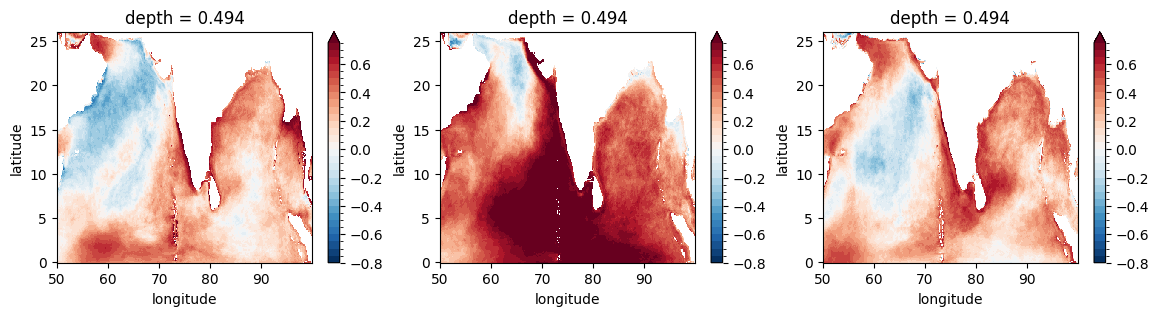

In [356]:
fig,ax=plt.subplots(1,3,figsize=(14,3))
ax=ax.ravel()
r1.plot(ax=ax[0],levels=np.arange(-0.8,.8,.05),cmap='RdBu_r')
r2.plot(ax=ax[1],levels=np.arange(-0.8,.8,.05),cmap='RdBu_r')
r3.plot(ax=ax[2],levels=np.arange(-0.8,.8,.05),cmap='RdBu_r')

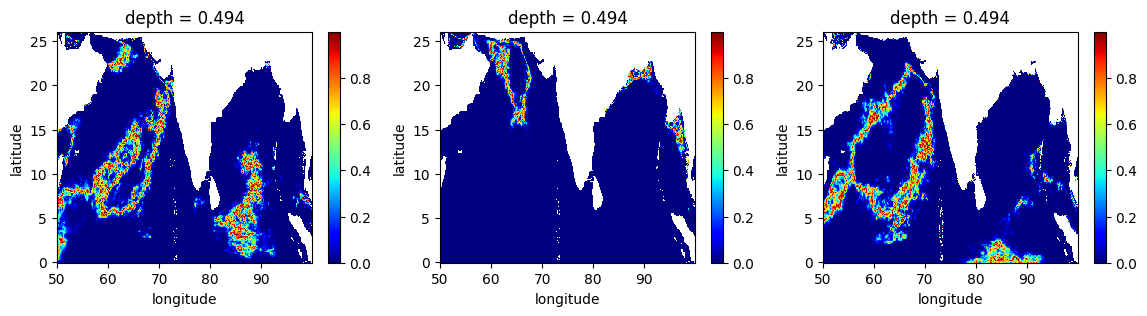

In [354]:
fig,ax=plt.subplots(1,3,figsize=(14,3))
ax=ax.ravel()
p1.plot(ax=ax[0],cmap='jet')
p2.plot(ax=ax[1],cmap='jet')
p3.plot(ax=ax[2],cmap='jet')

# EOF

In [3]:
dmi=pd.read_csv('/home/incois/prasanna/IO_trend/SINTEX_DMI.csv').set_index('time')['Obs'].to_xarray().sel(time=slice('1993','2021'))
nino=pd.read_csv('/home/incois/prasanna/IO_trend/SINTEX_Nino34.csv').set_index('time')['Obs'].to_xarray().sel(time=slice('1993','2021'))

# data prep for TA

In [4]:
import numpy as np
years_before=2
years_after=2
climatology_TA = []
climatology_std_TA = []

for year in range(1993,2021):
    start_year = year - years_before
    end_year = year + years_after + 1  

    subset_TA = ta.sel(Time=slice(f"{start_year}-01-01", f"{end_year}-12-31"))

    climatology_TA.append(subset_TA.groupby('Time.month').mean(dim='Time'))
    climatology_std_TA.append(subset_TA.groupby('Time.month').std(dim='Time'))
 
climatology_dataset1_TA = xr.concat(climatology_TA, dim='month')
climatology_dataset_std1_TA = xr.concat(climatology_std_TA, dim='month')

climatology_dataset1_TA['month']=ta.Time.values
climatology_dataset_std1_TA['month']=ta.Time.values

clim_TA=climatology_dataset1_TA.rename({'month':'Time'})
clim_std_TA=climatology_dataset_std1_TA.rename({'month':'Time'})

/home/incois/prasanna/anaconda3/envs/pyart_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/incois/prasanna/anaconda3/envs/pyart_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/incois/prasanna/anaconda3/envs/pyart_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/incois/prasanna/anaconda3/envs/pyart_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/incois/prasanna/anaconda3/envs/pyart_env/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeW

# EoF function

In [5]:
def EoF_function(data):
   
    coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(data,weights=wgts,center=True)
    eof2 = solver.eofsAsCovariance(neofs=3)
    pc2 = solver.pcs(npcs=3, pcscaling=1)
    variance_fractions = solver.varianceFraction()
    # print(variance_fractions[0:2]*100)
    for i in range(3):
        print(np.corrcoef(dmi,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
    print('\n','Nino3.4','\n')    
    for i in range(3):
        print(np.corrcoef(nino,pc2[:,i].sel(Time=slice('1993','2020')))[0][1])
        
    return   eof2, pc2, variance_fractions[0:3]*100   

In [6]:
data_TA=(ta-clim_TA)/clim_std_TA
data_TA_AS=data_TA.sel(Lon=slice(50,78))
data_TA_BoB=data_TA.sel(Lon=slice(78,100))

In [76]:
# data_nTA=(new_ta-clim_nTA)/clim_std_nTA
# data_nTA_AS=data_nTA.sel(Lon=slice(50,78))
# data_nTA_BoB=data_nTA.sel(Lon=slice(78,100))

In [7]:
EoF_TA_AS = EoF_function(data_TA_AS)[0:3]

print('\n')
# EoF_nTA_AS = EoF_function(data_nTA_AS)[0:3]

0.22281156767190824
-0.001390794692785504
0.08314824530607907

 Nino3.4 

0.32720479609241016
-0.27293462056425183
0.05097808660773963




In [93]:
# smooth = EoF_TA_AS[1].sel(mode=1).rolling(Time=3, center=True).mean()
# idx = np.where(np.isnan(smooth))
# np.corrcoef(nino[1:335],smooth[1:335]),np.corrcoef(dmi[1:335],smooth[1:335])

(array([[1.        , 0.48466213],
        [0.48466213, 1.        ]]),
 array([[1.        , 0.28092972],
        [0.28092972, 1.        ]]))

In [109]:
#(-EoF_TA_AS[0][1]*EoF_TA_AS[1][0].std()).plot()

In [55]:
print(f'{np.round(np.array(EoF_TA_AS[2][0]),2)}')

6.380000114440918


In [56]:
# EoF_TA_AS[0].plot()

# Only TA

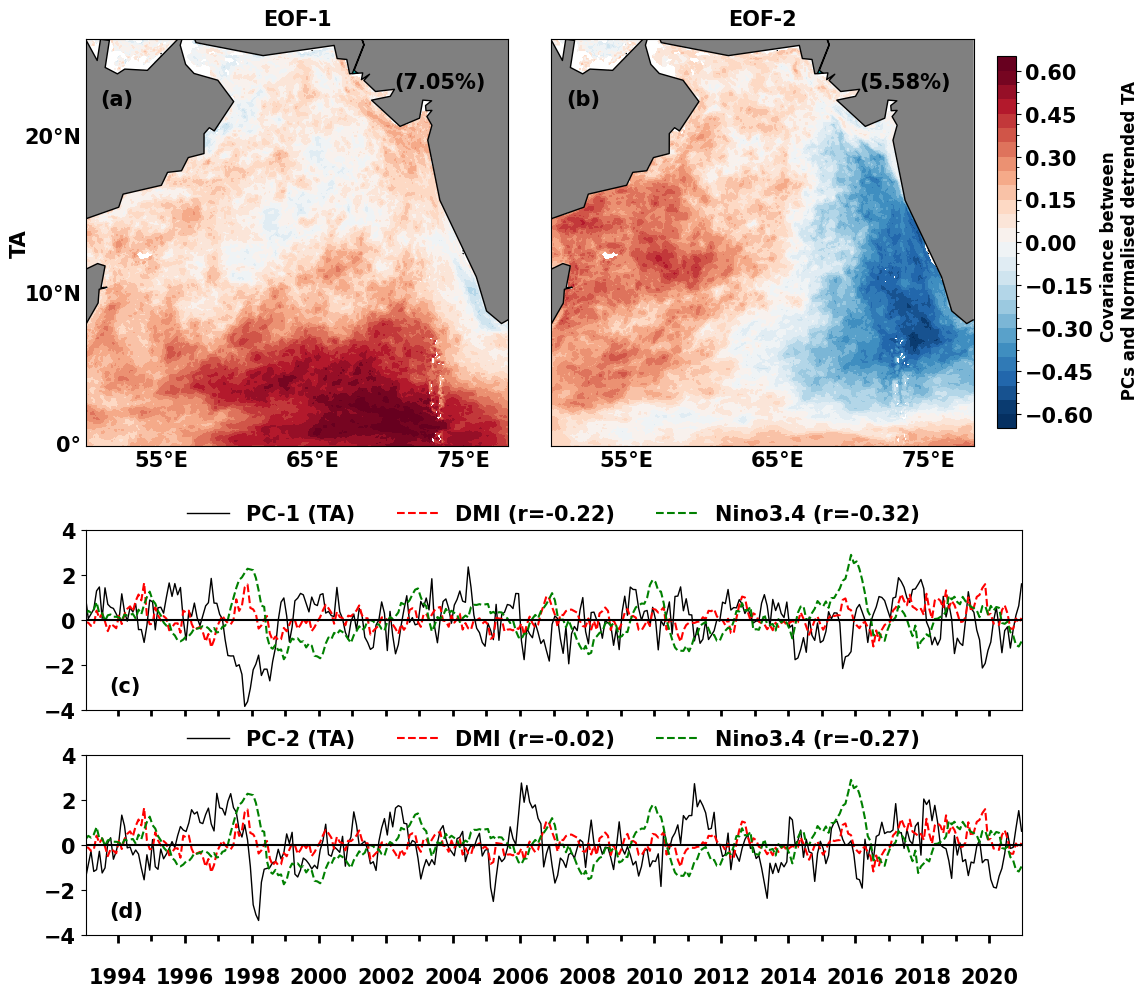

In [79]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.6,.601,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=78, resolution='c')
lon5,lat5=np.meshgrid(EoF_TA_AS[0].Lon,EoF_TA_AS[0].Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(1,2,figsize=(12,9))
ax=ax.ravel()
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')

p1=ax[0].contourf(lon5,lat5,-EoF_TA_AS[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,EoF_TA_AS[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')


fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace= .1, hspace=0.1)  
for i in range(2):      
    map.drawcoastlines(linewidth=1,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='w', fontsize=0, ax=ax[i],zorder=0)
    map.drawparallels(np.arange(-30, 30, 10), color='w', fontsize=0, ax=ax[i],zorder=0)
    if i in [0,1]:
        map.drawmeridians(np.arange(55, 120, 10), labels=[0,0,0,1], color='black', fontsize=15, ax=ax[i],zorder=0)
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=15, ax=ax[i],zorder=0)
    

# ax[1].set_yticks([])

cb2 = fig.colorbar(p1, ax=ax[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.02,pad=0.025)
cb2.ax.tick_params(labelsize=15)
cb2.minorticks_on()  
cb2.set_label('Covariance between \n PCs and Normalised detrended TA', rotation=90,fontsize=12,fontweight='bold')



left, bottom, width, height = [0.125, -0.025, .78, 0.2]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-EoF_TA_AS[1].sel(mode=0),c='black',label='PC-1',linewidth=1)
# ax1.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='r',label='PC-1')

ax1.plot(tim,dmi,c='red',linestyle='--')
ax1.plot(tim,nino,c='g',linestyle='--')
ax1.legend(['PC-1 (TA)','DMI (r=-0.22)','Nino3.4 (r=-0.32)'],ncol=3,loc='upper center',bbox_to_anchor=(0.25, 0.75, .5, 0.5),framealpha=0,fontsize=15)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])
ax1.yaxis.set_tick_params(which='major',labelsize=15,rotation=0)




left, bottom, width, height = [0.125, -.275, .78, 0.2]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,EoF_TA_AS[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_AS[1].sel(mode=0),c='r',label='PC-1')

ax3.plot(tim,dmi,c='red',linestyle='--')
ax3.plot(tim,nino,c='g',linestyle='--')
ax3.legend(['PC-2 (TA)','DMI (r=-0.02)','Nino3.4 (r=-0.27)'],ncol=3,loc='upper center',bbox_to_anchor=(0.25, 0.75, .5, 0.5),framealpha=0,fontsize=15)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])
ax3.yaxis.set_tick_params(which='major',labelsize=15,rotation=0)



ax1.text(0.73,.88,f'({EoF_TA_AS[2][0]:.2f}%)',fontsize=15,fontweight='bold',transform=ax[0].transAxes)
ax3.text(0.73,.88,f'({EoF_TA_AS[2][1]:.2f}%)',fontsize=15,fontweight='bold',transform=ax[1].transAxes)



ax[0].set_ylabel('TA',fontsize=15,fontweight='bold',labelpad=40)

ax[0].set_title('EOF-1',fontsize=15,fontweight='bold',pad=10)
ax[1].set_title('EOF-2',fontsize=15,fontweight='bold',pad=10)


xx,yy=map(51,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)



ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax3.text(0.025,0.1,'(d)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax3]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=15)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=15)
        if i in [0,1,2,3]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=15)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_AS_new_nTA_1180.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [81]:
 EoF_TA_BoB = EoF_function(data_TA_BoB)[0:3] 
print('\n')
EoF_nTA_BoB = EoF_function(data_nTA_BoB)[0:3]

0.3208079214048715
0.1293356917317271
0.03990544883238611

 Nino3.4 

0.37804707430386497
0.020029947963276677
0.12690717560413606




NameError: name 'data_nTA_BoB' is not defined

# BoB

# Only TA BoB

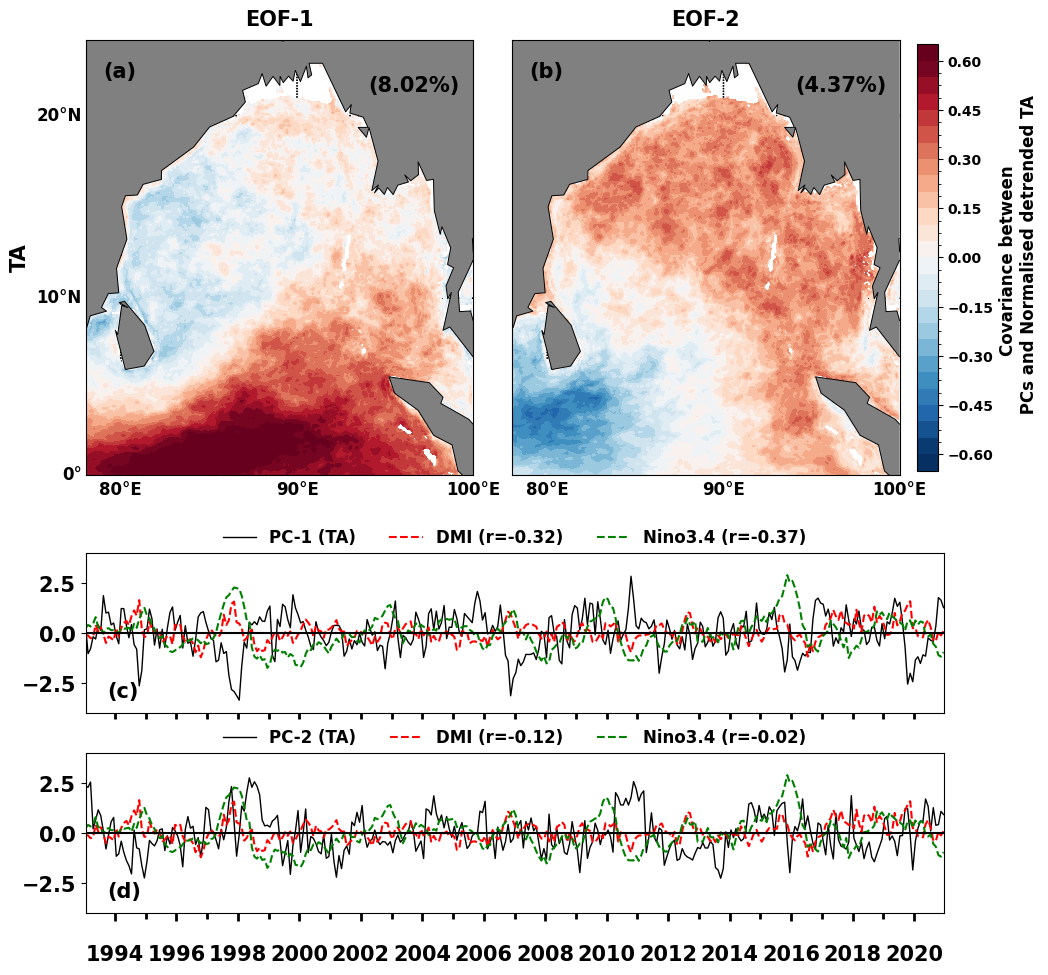

In [105]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.6,.601,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=24,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
lon5,lat5=np.meshgrid(EoF_TA_BoB[0].Lon,EoF_TA_BoB[0].Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(1,2,figsize=(11,8))
ax=ax.ravel()
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')

p1=ax[0].contourf(lon5,lat5,-EoF_TA_BoB[0].sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,-EoF_TA_BoB[0].sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')



fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace= 0.1, hspace=0.01)  
for i in range(2):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i],zorder=0)
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i],zorder=0)
    if i in [0,1]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i],zorder=0)
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i],zorder=0)
    

ax[1].set_yticks([])

cb2 = fig.colorbar(p1, ax=ax[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.025,pad=.02)
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between \n PCs and Normalised detrended TA', rotation=90,fontsize=12,fontweight='bold')


left, bottom, width, height = [0.125, -0.075, .78, 0.2]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-EoF_TA_BoB[1].sel(mode=0),c='black',label='PC-1',linewidth=1)
# ax1.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='r',label='PC-1')

ax1.plot(tim,dmi,c='red',linestyle='--')
ax1.plot(tim,nino,c='g',linestyle='--')
ax1.legend(['PC-1 (TA)','DMI (r=-0.32)','Nino3.4 (r=-0.37)'],ncol=3,loc='upper center',bbox_to_anchor=(0.25, 0.75, .5, 0.5),framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])





left, bottom, width, height = [0.125, -0.325, .78, 0.2]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,-EoF_TA_BoB[1].sel(mode=1),c='black',label='PC-2',linewidth=1)
# ax1.plot(tim,EoF_nTA_BoB[1].sel(mode=0),c='r',label='PC-1')

ax3.plot(tim,dmi,c='red',linestyle='--')
ax3.plot(tim,nino,c='g',linestyle='--')
ax3.legend(['PC-2 (TA)','DMI (r=-0.12)','Nino3.4 (r=-0.02)'],ncol=3,loc='upper center',bbox_to_anchor=(0.25, 0.75, .5, 0.5),framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])






ax1.text(0.73,.88,f'({EoF_TA_BoB[2][0]:.2f}%)',fontsize=15,fontweight='bold',transform=ax[0].transAxes)
ax3.text(0.73,.88,f'({EoF_TA_BoB[2][1]:.2f}%)',fontsize=15,fontweight='bold',transform=ax[1].transAxes)


ax[0].set_ylabel('TA',fontsize=15,fontweight='bold',labelpad=40)

ax[0].set_title('EOF-1',fontsize=15,fontweight='bold',pad=10)
ax[1].set_title('EOF-2',fontsize=15,fontweight='bold',pad=10)


xx,yy=map(79,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)

ax1.yaxis.set_tick_params(which='major',labelsize=15,rotation=0)
ax3.yaxis.set_tick_params(which='major',labelsize=15,rotation=0)



ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax3.text(0.025,0.1,'(d)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax3]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=15)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=15)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB_new.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')  

In [ ]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
lev=np.arange(-.4,.4,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=78, resolution='c')
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)
fig,ax = plt.subplots(1,2,figsize=(14,7))

#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,-eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.14, hspace=0.05)  
for i in range(2):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.17, 0.05, 0.675, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.4,.4,.05),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.18)','Nino3.4 (r=-0.35)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.013)','Nino3.4 (r=0.20)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.3,1.02,'EOF-1 (variance=8.42%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.52%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(51,22)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
# ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(d)',fontsize=15,transform=ax2.transAxes)
# ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax2]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_AS.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
plt.rcParams['font.weight']='bold'
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)
tim=ta.Time
lev=np.arange(-.6,.6,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
fig,ax = plt.subplots(1,3,figsize=(14,5.5))
#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')
ax[2].contourf(lon5,lat5,eof2.sel(mode=2).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.05)  
for i in range(3):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='gray',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1,2]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.215, 0.0, 0.6, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.6,.1),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.34)','Nino3.4 (r=-0.42)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,-nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.12)','Nino3.4 (r=0.01)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


left, bottom, width, height = [0.125, -1.4, .78, 0.4]
ax3 = fig.add_axes([left, bottom, width, height])
ax3.margins(x=0)
ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
ax3.plot(tim,dmi,c='red')
ax3.plot(tim,nino,c='blue')
ax3.legend(['PC-3','DMI (r=-0.09)','Nino3.4 (r=-0.12)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax3.axhline(y=0,c='black')
ax3.set_ylim([-4,4])


ax1.text(0.3,1.02,'EOF-1 (variance=9.05%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.22%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
ax3.text(1.4,1.02,'EOF-3 (variance=4.15%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(80,24)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(d)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(e)',fontsize=15,transform=ax2.transAxes)
ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)

for i, ax in enumerate([ax1,ax2,ax3]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0,1]:
            ax.set_xticks([])
        if i in [2]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
plt.rcParams['font.weight']='bold'

tim=ta.Time
# lev=np.arange(-.4,.4,0.05)
from mpl_toolkits.basemap import Basemap
lev=np.arange(-.6,.6,0.05)
from mpl_toolkits.basemap import Basemap
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=78, urcrnrlon=100, resolution='c')
# fig,ax = plt.subplots(1,3,figsize=(14,5.5))
lon5,lat5=np.meshgrid(eof2.Lon,eof2.Lat)
lon5,lat5=map(lon5,lat5)

fig,ax = plt.subplots(1,2,figsize=(12,7))

#ax[0].contourf(lon,lat,eof1.sel(mode=0).squeeze(),55,cmap='gist_rainbow_r')
p1=ax[0].contourf(lon5,lat5,eof2.sel(mode=0).squeeze(),55,cmap='RdBu_r',extend='both',levels=lev)
ax[1].contourf(lon5,lat5,eof2.sel(mode=1).squeeze(),55,cmap='RdBu_r',levels=lev,extend='both')

fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.1, hspace=0.05)  
for i in range(2):      
    map.drawcoastlines(linewidth=0.7,color='k', ax=ax[i])
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax[i])
    ax[i].tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(30, 120,10), color='black', fontsize=16, ax=ax[i])
    map.drawparallels(np.arange(-30, 30, 10), color='black', fontsize=16, ax=ax[i])
    if i in [0,1]:
        map.drawmeridians(np.arange(30, 120, 10), labels=[0,0,0,1], color='black', fontsize=12, ax=ax[i])
    if i in [0]:
        map.drawparallels(np.arange(-30, 30, 10), labels=[1,0,0,0], color='black', fontsize=12, ax=ax[i])
    

ax[1].set_yticks([])
cax2 = fig.add_axes([.17, 0.01, 0.675, 0.035])
cb2=plt.colorbar(p1,cax=cax2,extend=None,ticks=np.arange(-.6,.6,.1),pad=0.5,orientation='horizontal')
cb2.ax.tick_params(labelsize=10)
cb2.minorticks_on()  
cb2.set_label('Covariance between PCs and Normalised detrended TA', rotation=0,fontsize=12,fontweight='bold')
# #plt.colorbar()

left, bottom, width, height = [0.125, -0.5, .78, 0.4]
ax1 = fig.add_axes([left, bottom, width, height])
ax1.margins(x=0)
ax1.plot(tim,-pc2.sel(mode=0).squeeze(),c='black',label='PC-1')
ax1.plot(tim,dmi,c='red')
ax1.plot(tim,nino,c='blue')
ax1.legend(['PC-1','DMI (r=-0.34)','Nino3.4 (r=-0.42)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax1.axhline(y=0,c='black')
ax1.set_ylim([-4,4])


# ax1.xaxis.set_major_locator(MonthLocator(bymonth=7,bymonthday=16)


ax1.xaxis.set_minor_locator(YearLocator(2,month=1,day=1))
ax1.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
# ax1.xaxis.set_minor_formatter(DateFormatter("\n%Y"))
ax1.xaxis.set_tick_params(which='minor',labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax1.set_xticks([])



left, bottom, width, height = [0.125, -.95, .78, 0.4]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.margins(x=0)
ax2.plot(tim,pc2.sel(mode=1).squeeze(),c='black')
ax2.plot(tim,dmi,c='red')
ax2.plot(tim,nino,c='blue')
ax2.legend(['PC-2','DMI (r=-0.12)','Nino3.4 (r=0.01)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
ax2.axhline(y=0,c='black')
ax2.set_ylim([-4,4])


ax2.xaxis.set_minor_locator(YearLocator(2,month=1,day=15))
ax2.tick_params(axis='x',which='minor',length=5, width=2,labelsize=10,rotation=45)
ax2.xaxis.set_tick_params(labelsize=12,rotation=45)
# ax1.set_ylabel('PC-1',fontweight='bold',fontsize=12)
ax2.set_xticks([])


# left, bottom, width, height = [0.125, -1.4, .78, 0.4]
# ax3 = fig.add_axes([left, bottom, width, height])
# ax3.margins(x=0)
# ax3.plot(tim,pc2.sel(mode=2).squeeze(),c='black')
# ax3.plot(tim,dmi,c='red')
# ax3.plot(tim,nino,c='blue')
# ax3.legend(['PC-3','DMI (r=-0.13)','Nino3.4 (r=-0.18)'],ncol=3,loc='lower center',framealpha=0,fontsize=12)
# ax3.axhline(y=0,c='black')
# ax3.set_ylim([-4,4])
# ax3.set_xticks([])

ax1.text(0.3,1.02,'EOF-1 (variance=9.05%)',fontsize=12,fontweight='bold',transform=ax[0].transAxes)
ax2.text(0.3,1.02,'EOF-2 (variance=5.22%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)
# ax3.text(1.45,1.02,'EOF-3 (variance=4.27%)',fontsize=12,fontweight='bold',transform=ax[1].transAxes)


xx,yy=map(80,24)
ax[0].text(xx,yy,'(a)',fontsize=15)
ax[1].text(xx,yy,'(b)',fontsize=15)
# ax[2].text(xx,yy,'(c)',fontsize=15)

ax1.text(0.025,0.1,'(c)',fontsize=15,transform=ax1.transAxes)
ax2.text(0.025,0.1,'(d)',fontsize=15,transform=ax2.transAxes)
# ax3.text(0.025,0.1,'(f)',fontsize=15,transform=ax3.transAxes)


for i, ax in enumerate([ax1,ax2]):
        ax.xaxis.set_major_locator(YearLocator(2))
        ax.tick_params(axis='x',which='major', length=6,width=2,pad=0,labelsize=13)
        ax.xaxis.set_minor_locator(YearLocator(1))
        ax.tick_params(axis='x',which='minor',length=4, width=2,labelsize=13)
        if i in [0,1]:
#             ax[i].xaxis.set_minor_formatter(FuncFormatter(m_fmt))
            ax.xaxis.set_tick_params(labelsize=14)
        if i in [0]:
            ax.set_xticks([])
        if i in [1]:
            ax.xaxis.set_major_formatter(DateFormatter("\n%Y"))  

# plt.savefig('EOF_BoB.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
def seasonal_decomposition(x):
    if np.all(np.isnan(x)):
            return np.nan_to_num(x)
    result = seasonal_decompose(x, model='additive',period=12)
    return result.seasonal  


In [ ]:
data_3d=ta

season = xr.apply_ufunc(
    seasonal_decomposition,
    data_3d,
    input_core_dims=[['Time']],
    output_core_dims=[['Time']],
    vectorize=True
)
deseasonal_TA = data_3d - season


detrend_TA=deseasonal_TA.fillna(1)
detrend_TA=xt.detrend(detrend_TA,dim='Time',detrend_type='linear')

In [ ]:
def eeof(data):
    coslat = np.cos(np.deg2rad(data.coords['Lat'].values))
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(data,weights=wgts,center=False)
    # eof1 = solver.eofsAsCorrelation(neofs=3)
    # pc1 = solver.pcs(npcs=3, pcscaling=1)
    eof2 = solver.eofsAsCovariance(neofs=3)
    pc2 = solver.pcs(npcs=3, pcscaling=1)
    variance_fractions = solver.varianceFraction()
    return eof2,pc2,variance_fractions


In [ ]:
res=eeof(detrend_TA)
print('\n','DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4','\n')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])

In [ ]:
print('AS')
res=eeof(detrend_TA.sel(Lon=slice(50,78)))
print('DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
    
print(np.array(res[2][:3]*100))        

In [ ]:
print('BoB')
res=eeof(detrend_TA.sel(Lon=slice(78,100)))
print('DMI','\n')  
for i in range(3):
    print(np.corrcoef(dmi.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print('\n','Nino3.4')    
for i in range(3):
    print(np.corrcoef(nino.sel(time=slice('1992','2019')),res[1][:,i].sel(Time=slice('1993','2019')))[0][1])
print(np.array(res[2][:3]*100))    

In [ ]:
fig,ax=plt.subplots(figsize=(14,3))
ay=ax.twinx()
ax.plot(detrend_TA.sel(Lon=slice(78,100)).mean(dim=['Lon','Lat']),c='red')
ay.plot(dmi.sel(time=slice('1992','2019')))

In [ ]:
fig,ax=plt.subplots(figsize=(14,3))
ay=ax.twinx()
ax.plot(detrend_TA.sel(Lon=slice(50,78)).mean(dim=['Lon','Lat']),c='red')
ay.plot(dmi.sel(time=slice('1992','2019')))

In [ ]:
ta_clim=ta.groupby('Time.month').mean()

In [ ]:
full_mld=xr.open_dataset('/home/prasanna/GLORY3D/TA_PAPER/COP_mld_TA.nc').mlotst\

In [ ]:
mld_clim=full_mld.groupby('time.month').mean()

In [ ]:
month_labels=[
  "Jan",
  "Feb",
  "Mar",
  "Apr",
  "May",
  "Jun",
  "Jul",
  "Aug",
  "Sep",
  "Oct",
  "Nov",
  "Dec"
];

In [ ]:
fig, axn = plt.subplots(4, 3, sharex=True, sharey=True,figsize=(26,18))
fig.subplots_adjust(top=0.93, hspace=0.1, wspace=0.08)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=100, resolution='c')
ds = ta_clim
lon1, lat1 = np.meshgrid(ds.Lon, ds.Lat) 
lon2, lat2 = map(lon1, lat1)

for i, ax in enumerate(axn.flat):
    pl = map.pcolormesh(lon2, lat2, ds.isel(month=i), cmap='jet', shading = 'gouraud', edgecolors ='face', ax=ax)
    ax.set_title(month_labels[i],fontsize=20,fontweight='bold')
    
    if i in [11,0,1]:
        contour = ax.contour(lon2,lat2,mld_clim[i], levels=[15,40],colors='black',linewidths=2.5)  
        ax.clabel(contour, inline=1, fontsize=18) 
    elif i in [8]:
        contour = ax.contour(lon2,lat2,mld_clim[i], levels=[15,25,60],colors='black',linewidths=2.5)  
        ax.clabel(contour, inline=1, fontsize=18) 
    else:
        contour = ax.contour(lon2,lat2,mld_clim[i], levels=[15,30,45,60],colors='black',linewidths=2.5)  
        ax.clabel(contour, inline=1, fontsize=18) 
    
    map.drawcoastlines(ax=ax)
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax)
    ax.tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(50, 100,10), color='k', fontsize=8, ax=ax)
    map.drawparallels(np.arange(0, 30, 5), color='k', fontsize=8, ax=ax)
    if i in [9, 10, 11]:
        map.drawmeridians(np.arange(50, 100.5, 10), labels=[0,0,0,1], color='k', fontsize=12, ax=ax)
    if i in [0, 3, 6, 9]:
        map.drawparallels(np.arange(0, 40, 5), labels=[1,0,0,0], color='k', fontsize=12, ax=ax)
        
cbar = fig.colorbar(pl, ax=axn[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.03)  
cbar.ax.tick_params(labelsize=15)
# plt.savefig('Overlay_monthly1.png', transparent=None, dpi=400, bbox_inches='tight', facecolor='white', edgecolor='white')            

In [ ]:
fig, axn = plt.subplots(4, 3, sharex=True, sharey=True,figsize=(26,18))
fig.subplots_adjust(top=0.93, hspace=0.1, wspace=0.08)
map = Basemap(projection='merc', llcrnrlat=0, urcrnrlat=26,
            llcrnrlon=50, urcrnrlon=100, resolution='c')
ds = ta_clim
lon1, lat1 = np.meshgrid(ds.Lon, ds.Lat) 
lon2, lat2 = map(lon1, lat1)

for i, ax in enumerate(axn.flat):
    pl = map.pcolormesh(lon2, lat2, ds.isel(month=i), cmap='jet', shading = 'gouraud', edgecolors ='face', ax=ax)
    ax.set_title(month_labels[i],fontsize=20,fontweight='bold')
    
#     if i in [11,0,1]:
#         contour = ax.contour(lon2,lat2,mld_clim[i], levels=[15,40],colors='black',linewidths=2.5)  
#         ax.clabel(contour, inline=1, fontsize=18) 
#     elif i in [8]:
#         contour = ax.contour(lon2,lat2,mld_clim[i], levels=[15,25,60],colors='black',linewidths=2.5)  
#         ax.clabel(contour, inline=1, fontsize=18) 
#     else:
    contour = ax.contour(lon2,lat2,mld_clim[i], levels=5,colors='black',linewidths=2.5)  
    ax.clabel(contour, inline=1, fontsize=18) 

    map.drawcoastlines(ax=ax)
    map.fillcontinents(color='grey',lake_color='aqua', ax=ax)
    ax.tick_params(axis='both', labelsize=8)
    map.drawmeridians(np.arange(50, 100,10), color='k', fontsize=8, ax=ax)
    map.drawparallels(np.arange(0, 30, 5), color='k', fontsize=8, ax=ax)
    if i in [9, 10, 11]:
        map.drawmeridians(np.arange(50, 100.5, 10), labels=[0,0,0,1], color='k', fontsize=12, ax=ax)
    if i in [0, 3, 6, 9]:
        map.drawparallels(np.arange(0, 40, 5), labels=[1,0,0,0], color='k', fontsize=12, ax=ax)
        
cbar = fig.colorbar(pl, ax=axn[:], extend='both', extendfrac='auto', extendrect=True, fraction = 0.03)  
cbar.ax.tick_params(labelsize=15)

In [ ]:
mld_clim[9].plot(cmap='jet')

In [354]:
salt=xr.open_dataset('/home/kunal/RECCAP/output_clubbed/post_process/salt/Sea-surface_salinity_monthly.nc')
salt

<xarray.Dataset>
Dimensions:  (LON_RHO: 1381, LAT_RHO: 843, DEPTH: 1, TIME: 480)
Coordinates:
  * LON_RHO  (LON_RHO) float32 25.0 25.08 25.17 25.25 ... 139.8 139.9 140.0
  * LAT_RHO  (LAT_RHO) float32 -36.0 -35.93 -35.87 -35.8 ... 29.91 29.98 30.05
  * DEPTH    (DEPTH) float32 0.0
  * TIME     (TIME) datetime64[ns] 1980-01-24 1980-02-23 ... 2019-12-25
Data variables:
    SALT2    (TIME, DEPTH, LAT_RHO, LON_RHO) float64 ...
Attributes:
    CDI:          Climate Data Interface version 1.6.3 (http://code.zmaw.de/p...
    Conventions:  CF-1.6
    history:      Fri Dec 03 17:41:14 2021: cdo monmean Sea-surface_salinity....
    CDO:          Climate Data Operators version 1.6.3 (http://code.zmaw.de/p...

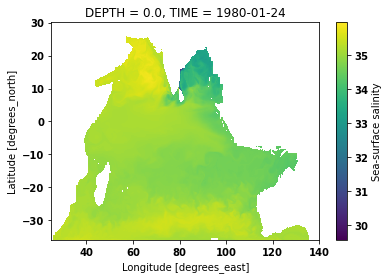

In [356]:
salt.isel(TIME=0).SALT2.plot()

In [357]:
salt_EIO=salt.sel(LON_RHO=slice(30,120),LAT_RHO=slice(-30,30)).squeeze()

In [358]:
salt_EIO

<xarray.Dataset>
Dimensions:  (LON_RHO: 1081, LAT_RHO: 756, TIME: 480)
Coordinates:
  * LON_RHO  (LON_RHO) float32 30.0 30.08 30.17 30.25 ... 119.8 119.9 120.0
  * LAT_RHO  (LAT_RHO) float32 -30.0 -29.92 -29.85 -29.78 ... 29.83 29.91 29.98
    DEPTH    float32 0.0
  * TIME     (TIME) datetime64[ns] 1980-01-24 1980-02-23 ... 2019-12-25
Data variables:
    SALT2    (TIME, LAT_RHO, LON_RHO) float64 ...
Attributes:
    CDI:          Climate Data Interface version 1.6.3 (http://code.zmaw.de/p...
    Conventions:  CF-1.6
    history:      Fri Dec 03 17:41:14 2021: cdo monmean Sea-surface_salinity....
    CDO:          Climate Data Operators version 1.6.3 (http://code.zmaw.de/p...

In [359]:
IO_2000_2005=salt_EIO.sel(TIME=slice('2000','2005'))

In [360]:
tr_IO_2000_2005=xr.apply_ufunc(calculate_trend, IO_2000_2005,input_core_dims=[['TIME']],vectorize=True,dask='parallelized',output_dtypes=[float])

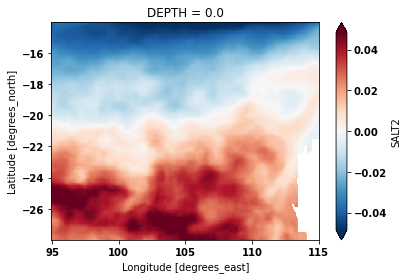

In [372]:
(tr_IO_2000_2005).SALT2.sel(LON_RHO=slice(95,115),LAT_RHO=slice(-28,-14)).plot(robust=True)

In [364]:
IO_2005_2010=salt_EIO.sel(TIME=slice('2006','2010'))

In [365]:
tr_IO_2005_2010=xr.apply_ufunc(calculate_trend, IO_2005_2010,input_core_dims=[['TIME']],vectorize=True,dask='parallelized',output_dtypes=[float])

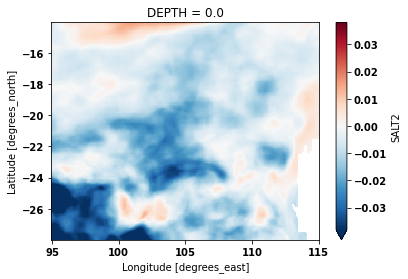

In [373]:
(tr_IO_2005_2010).sel(LON_RHO=slice(95,115),LAT_RHO=slice(-28,-14)).SALT2.plot(robust=True)

In [375]:
IO_2011_2016=salt_EIO.sel(TIME=slice('2011','2016'))

In [376]:
tr_IO_2011_2016=xr.apply_ufunc(calculate_trend, IO_2011_2016,input_core_dims=[['TIME']],vectorize=True,dask='parallelized',output_dtypes=[float])

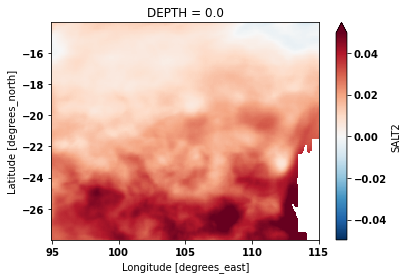

In [377]:
(tr_IO_2011_2016).sel(LON_RHO=slice(95,115),LAT_RHO=slice(-28,-14)).SALT2.plot(robust=True)

In [378]:
IO_95_2000=salt_EIO.sel(TIME=slice('1995','2000')).sel(LON_RHO=slice(95,115),LAT_RHO=slice(-28,-14)).SALT2

In [379]:
tr_IO_95_2000=xr.apply_ufunc(calculate_trend, IO_95_2000,input_core_dims=[['TIME']],vectorize=True,dask='parallelized',output_dtypes=[float])

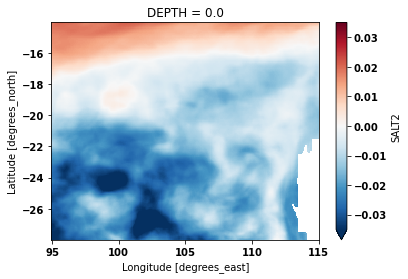

In [380]:
tr_IO_95_2000.plot(robust=True)